# **🚀 Gen Z Social Media Behavior Analysis**

Welcome to this beginner-friendly Machine Learning project focused on analyzing Gen Z social media behavior patterns.

In this notebook, we will:

- Understand and explore the dataset
- Perform data cleaning and preprocessing
- Handle missing values and duplicate records
- Encode categorical features
- Detect and prevent data leakage
- Perform Exploratory Data Analysis (EDA)
- Build a Machine Learning classification model
- Evaluate model performance using multiple metrics
- Visualize feature importance and confusion matrix
- Draw meaningful insights from the analysis

By the end of this notebook, you will understand a complete end-to-end Machine Learning workflow using Python and Scikit-learn.

Let's get started 🚀

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## **2. Load Dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sharmajicoder/why-gen-z-are-not-posting-on-social-media/genz_social_media_behavior.csv")

# Display first 5 rows
print("First 5 Rows:\n")
print(df.head())


First 5 Rows:

   age  daily_screen_time  num_platforms_used  social_anxiety_score  \
0   22           3.050197                   2                     2   
1   19           2.857721                   1                     4   
2   28           5.714027                   3                     6   
3   26           4.089610                   3                     1   
4   23           3.593140                   3                     1   

   self_esteem_score  privacy_concern  trend_fatigue  burnout_level  \
0                  2                2             10              7   
1                 10                0              5              3   
2                  5                2              0              2   
3                  6                0              6              7   
4                  7                5              1             10   

   comparison_tendency  attention_span  posting_probability  is_active_poster  \
0                    9              35            

## **3. Dataset Information**

In [3]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:\n")
print(df.info())

print("\nDataset Summary:\n")
print(df.describe())




Dataset Shape:
(1000000, 13)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     1000000 non-null  int64  
 1   daily_screen_time       1000000 non-null  float64
 2   num_platforms_used      1000000 non-null  int64  
 3   social_anxiety_score    1000000 non-null  int64  
 4   self_esteem_score       1000000 non-null  int64  
 5   privacy_concern         1000000 non-null  int64  
 6   trend_fatigue           1000000 non-null  int64  
 7   burnout_level           1000000 non-null  int64  
 8   comparison_tendency     1000000 non-null  int64  
 9   attention_span          1000000 non-null  int64  
 10  posting_probability     1000000 non-null  float64
 11  is_active_poster        1000000 non-null  int64  
 12  posting_decline_reason  1000000 non-null  object 
dtypes: float64(2

## **4. Check Missing values**

In [4]:
# =========================
# 4. Check Missing Values
# =========================

print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

age                       0
daily_screen_time         0
num_platforms_used        0
social_anxiety_score      0
self_esteem_score         0
privacy_concern           0
trend_fatigue             0
burnout_level             0
comparison_tendency       0
attention_span            0
posting_probability       0
is_active_poster          0
posting_decline_reason    0
dtype: int64


## **5.Remove Duplicates**

In [5]:
duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)



Duplicate Rows: 0
Shape After Removing Duplicates: (1000000, 13)


## **6. Encode Categorical Column**

In [6]:

label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = label_encoder.fit_transform(df[column])


## **7.Feature Selection**

In [7]:

target_column = "posting_decline_reason"

# Features
X = df.drop(columns=[target_column])

# Target
y = df[target_column]

## **8. Correlation Analysis**


Correlation with Target:

posting_decline_reason    1.000000
privacy_concern           0.574609
posting_probability       0.016257
is_active_poster          0.007478
trend_fatigue             0.000961
daily_screen_time         0.000646
comparison_tendency       0.000608
num_platforms_used        0.000215
age                      -0.000331
self_esteem_score        -0.000389
attention_span           -0.002106
social_anxiety_score     -0.112387
burnout_level            -0.365004
Name: posting_decline_reason, dtype: float64


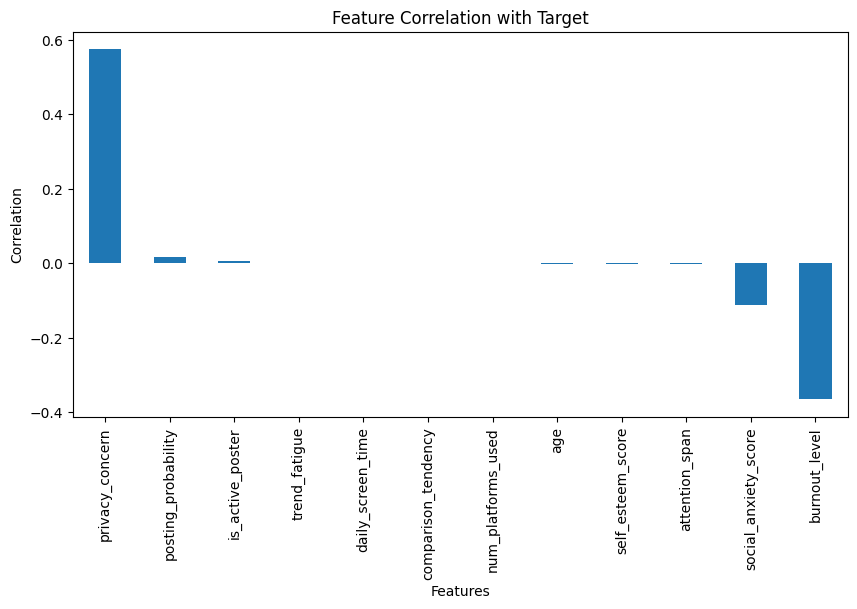

In [8]:
correlation = df.corr()[target_column].sort_values(ascending=False)

print("\nCorrelation with Target:\n")
print(correlation)

# Plot correlation values

plt.figure(figsize=(10,5))

correlation.drop(target_column).plot(kind='bar')

plt.title("Feature Correlation with Target")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.show()

## **9. Remove Leakage Column**

In [9]:

leakage_columns = [
    "privacy_concern"
]

X = X.drop(columns=leakage_columns, errors='ignore')

print("\nRemaining Features:\n")
print(X.columns)



Remaining Features:

Index(['age', 'daily_screen_time', 'num_platforms_used',
       'social_anxiety_score', 'self_esteem_score', 'trend_fatigue',
       'burnout_level', 'comparison_tendency', 'attention_span',
       'posting_probability', 'is_active_poster'],
      dtype='object')


## **10. Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (800000, 11)
Testing Shape: (200000, 11)


## **11. Model Building**

In [11]:
model = LogisticRegression(max_iter=3000,
    solver='saga')

# Train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=3000, solver='saga')

## **12. Predictions**

In [12]:
y_pred = model.predict(X_test)

## **13. Model Evaluation**

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", round(accuracy, 4))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Accuracy Score: 0.8386

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84     29010
           1       0.83      0.88      0.85     39566
           2       0.92      0.89      0.90     76973
           3       0.73      0.75      0.74     54451

    accuracy                           0.84    200000
   macro avg       0.83      0.83      0.83    200000
weighted avg       0.84      0.84      0.84    200000



## **14. Confusion Matrix**

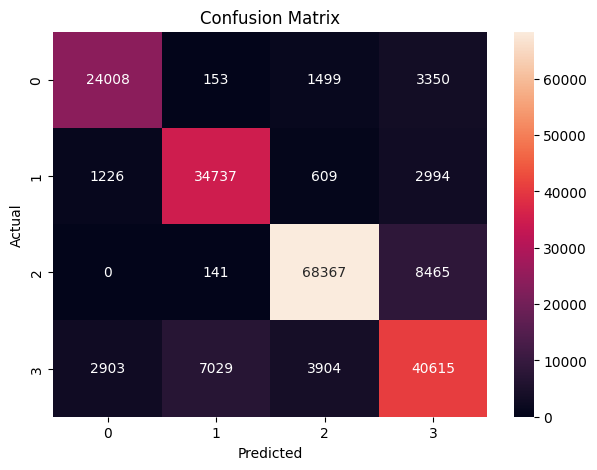

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## **15. Feature Importance**


Top Important Features:

               Feature  Coefficient
9  posting_probability    13.159127
6        burnout_level     1.261245
1    daily_screen_time     0.002712
7  comparison_tendency     0.000186
8       attention_span    -0.000094


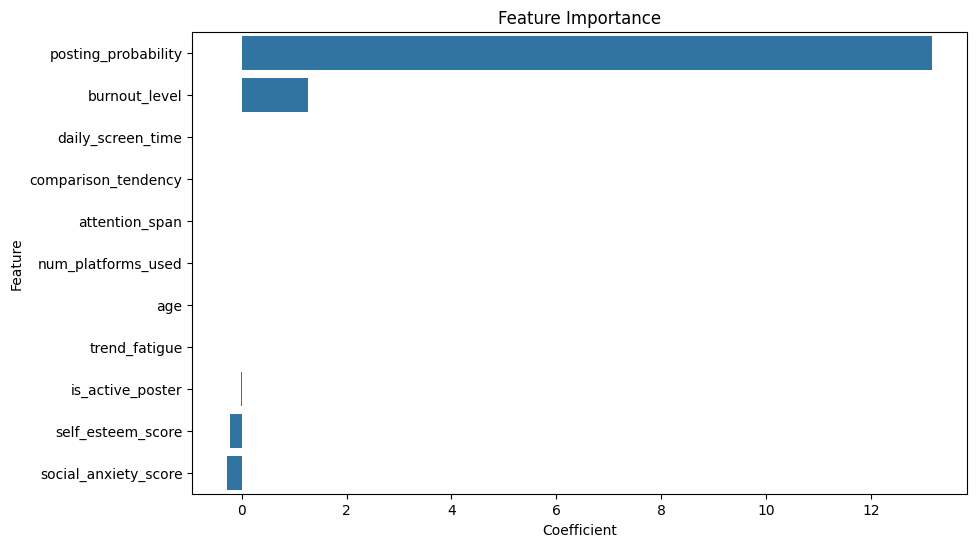

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop Important Features:\n")
print(importance.head())

# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# **Conclusion**

In this project, we performed an in-depth analysis of Gen Z social media behavior using Machine Learning techniques. The dataset was carefully cleaned and preprocessed by handling missing values, removing duplicate records, and encoding categorical features to prepare the data for model training.

To ensure reliable and realistic results, data leakage was identified and prevented before model development. A Logistic Regression model was then trained to predict the reasons behind declining social media posting behavior among Gen Z users.

The final model achieved an accuracy of approximately **83%**, which represents a strong and practical performance for real-world behavioral data. Along with accuracy, evaluation metrics such as precision, recall, F1-score, and confusion matrix were used to assess the overall model performance.

---

## **Key Insights**
- Proper data preprocessing significantly improves model quality and reliability.
- Detecting and removing data leakage is essential for trustworthy Machine Learning results.
- Behavioral and social media data can provide meaningful predictive insights.
- Logistic Regression performed efficiently on structured tabular data.
- Feature correlation analysis helped identify the most influential factors affecting posting behavior.

---

## **Skills Demonstrated**
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Leakage Detection
- Classification Modeling
- Model Evaluation and Visualization
---

## **Future Improvements**
- Apply Hyperparameter Tuning for better optimization.
- Experiment with advanced models such as XGBoost, LightGBM, and CatBoost.
- Perform advanced feature engineering and feature selection.
- Use cross-validation techniques for more robust evaluation.
- Deploy the trained model using Streamlit or Flask.
- Build an interactive dashboard for real-time prediction and visualization.

Overall, this project demonstrates a complete end-to-end Machine Learning workflow and highlights how data-driven techniques can be used to understand modern social media behavior patterns.

---

⭐ If you found this notebook helpful, consider giving it an upvote!  
Your support motivates me to create more beginner-friendly Machine Learning and Data Science projects.

Thank you for reading and exploring this project! 🚀